## Dogs vs. Cats Classification

Select free T4 GPU in Runtime settings

## Download data

In [1]:
!pip install -q gdown
!gdown https://drive.google.com/uc?id=12WhCCpKTWpeBztLegcoYx2gMo2KbaxDG

Downloading...
From (original): https://drive.google.com/uc?id=12WhCCpKTWpeBztLegcoYx2gMo2KbaxDG
From (redirected): https://drive.google.com/uc?id=12WhCCpKTWpeBztLegcoYx2gMo2KbaxDG&confirm=t&uuid=be642a53-6d0e-44c0-9786-f9453a2adb58
To: d:\Project\python\1GN\dogs-vs-cats.zip

  0%|          | 0.00/852M [00:00<?, ?B/s]
  0%|          | 1.57M/852M [00:00<01:03, 13.3MB/s]
  0%|          | 3.15M/852M [00:00<00:58, 14.4MB/s]
  1%|          | 5.24M/852M [00:00<00:53, 15.9MB/s]
  1%|          | 7.34M/852M [00:00<00:51, 16.4MB/s]
  1%|          | 9.44M/852M [00:00<00:54, 15.6MB/s]
  1%|▏         | 11.5M/852M [00:00<00:53, 15.7MB/s]
  2%|▏         | 13.6M/852M [00:00<00:51, 16.1MB/s]
  2%|▏         | 15.7M/852M [00:00<00:50, 16.6MB/s]
  2%|▏         | 17.8M/852M [00:01<00:52, 16.0MB/s]
  2%|▏         | 19.9M/852M [00:01<00:50, 16.5MB/s]
  3%|▎         | 22.0M/852M [00:01<00:49, 16.9MB/s]
  3%|▎         | 24.6M/852M [00:01<00:45, 18.3MB/s]
  3%|▎         | 27.3M/852M [00:01<00:42, 19.4MB/s]
  3%

In [4]:
import zipfile

with zipfile.ZipFile('dogs-vs-cats.zip', 'r') as zip_file:
    zip_file.extractall('data')

with zipfile.ZipFile('data/train.zip', 'r') as zip_file:
    zip_file.extractall('data/')

In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Paths
base_dir = 'data/train'
train_dir = 'data/train_split'
val_dir = 'data/val_split'

# Create directories
os.makedirs(os.path.join(train_dir, 'dogs'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'cats'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'dogs'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'cats'), exist_ok=True)

# Split data
filenames = os.listdir(base_dir)
train_files, val_files = train_test_split(filenames, test_size=0.2, random_state=42)

for file in train_files:
    if 'dog' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(train_dir, 'dogs', file))
    elif 'cat' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(train_dir, 'cats', file))

for file in val_files:
    if 'dog' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(val_dir, 'dogs', file))
    elif 'cat' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(val_dir, 'cats', file))

## Create data generators

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


## Create basic CNN classification model

In [7]:
from tensorflow.keras import models, layers

# Build the model
model_basic = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_basic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train basic model

In [6]:
history_model_basic = model_basic.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)

d:\Project\python\1GN\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 417ms/step - accuracy: 0.5769 - loss: 0.6684 - val_accuracy: 0.7376 - val_loss: 0.5251
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 145ms/step - accuracy: 0.7640 - loss: 0.4814 - val_accuracy: 0.7960 - val_loss: 0.4411
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.8162 - loss: 0.4039 - val_accuracy: 0.8098 - val_loss: 0.4282
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.8621 - loss: 0.3232 - val_accuracy: 0.8114 - val_loss: 0.4226
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.8997 - loss: 0.2366 - val_accuracy: 0.8356 - val_loss: 0.4136
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 214ms/step - accuracy: 0.9425 - loss: 0.1472 - val_accuracy: 0.8258 - val_loss: 0.4698
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.9748 - loss: 0.0753 - val_accuracy: 0.8256 - val_loss: 0.6066
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 110s 176ms/step - accuracy: 0.9870 - los

## Plot accuracy and loss

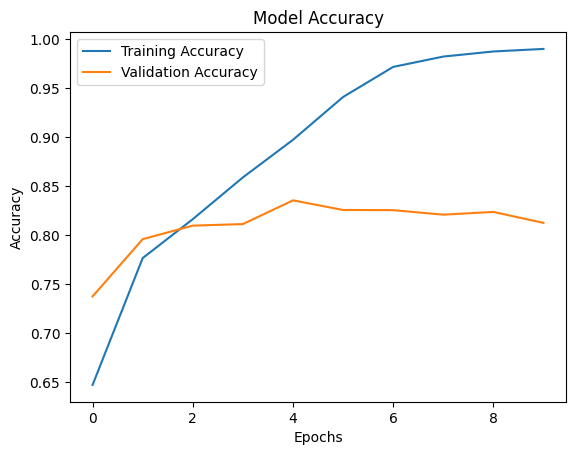

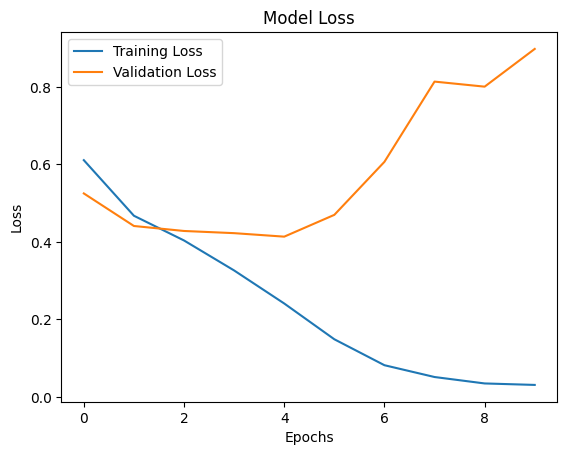

In [7]:
plt.plot(history_model_basic.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_basic.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_basic.history['loss'], label='Training Loss')
plt.plot(history_model_basic.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Add regularization

Add different regularization methods as described in the lab instructions and evaluate results.

### Add Dropout

In [16]:
from tensorflow.keras import models, layers

# Build the model
model_dropout = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history_model_dropout = model_dropout.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 275s 439ms/step - accuracy: 0.5101 - loss: 0.7016 - val_accuracy: 0.5640 - val_loss: 0.6821
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 179ms/step - accuracy: 0.5658 - loss: 0.6815 - val_accuracy: 0.5990 - val_loss: 0.6647
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 154ms/step - accuracy: 0.6194 - loss: 0.6501 - val_accuracy: 0.7248 - val_loss: 0.5739
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 220ms/step - accuracy: 0.7152 - loss: 0.5658 - val_accuracy: 0.7602 - val_loss: 0.4855
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 209ms/step - accuracy: 0.7603 - loss: 0.5048 - val_accuracy: 0.8052 - val_loss: 0.4297
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.7872 - loss: 0.4613 - val_accuracy: 0.8068 - val_loss: 0.4197
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 135s 217ms/step - accuracy: 0.7998 - loss: 0.4438 - val_accuracy: 0.8158 - val_loss: 0.4201
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 178ms/step - accuracy: 0.8086 - 

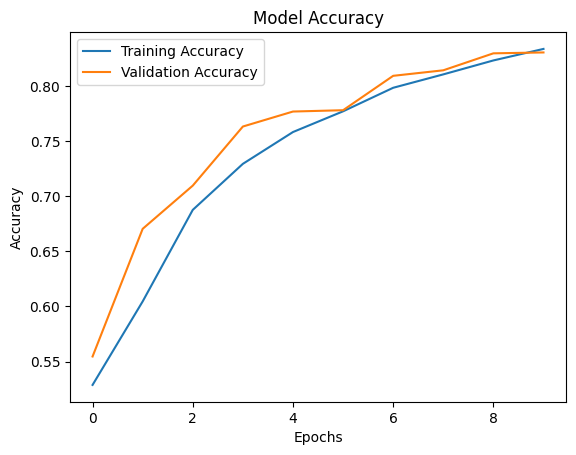

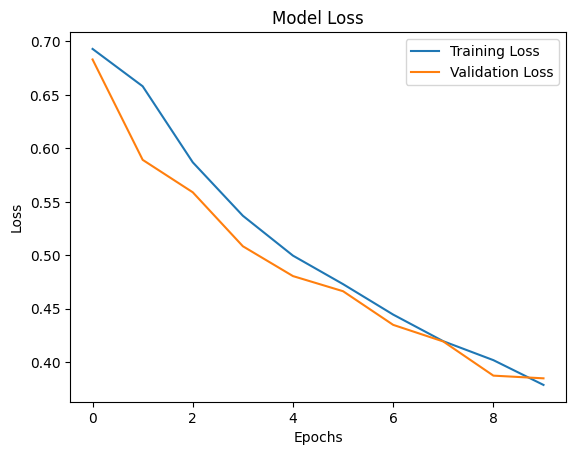

In [18]:
plt.plot(history_model_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_dropout.history['loss'], label='Training Loss')
plt.plot(history_model_dropout.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
from tensorflow.keras import models, layers

# Build the model
model_dropout = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history_model_dropout = model_dropout.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.5298 - loss: 0.7338 - val_accuracy: 0.5956 - val_loss: 0.6613
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.6357 - loss: 0.6346 - val_accuracy: 0.6372 - val_loss: 0.6098
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 159ms/step - accuracy: 0.6772 - loss: 0.5993 - val_accuracy: 0.7428 - val_loss: 0.5765
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.7080 - loss: 0.5618 - val_accuracy: 0.7018 - val_loss: 0.5499
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.7409 - loss: 0.5287 - val_accuracy: 0.7604 - val_loss: 0.5112
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 159ms/step - accuracy: 0.7568 - loss: 0.5081 - val_accuracy: 0.7512 - val_loss: 0.4972
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 162ms/step - accuracy: 0.7689 - loss: 0.4904 - val_accuracy: 0.7512 - val_loss: 0.4885
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.7756 - loss:

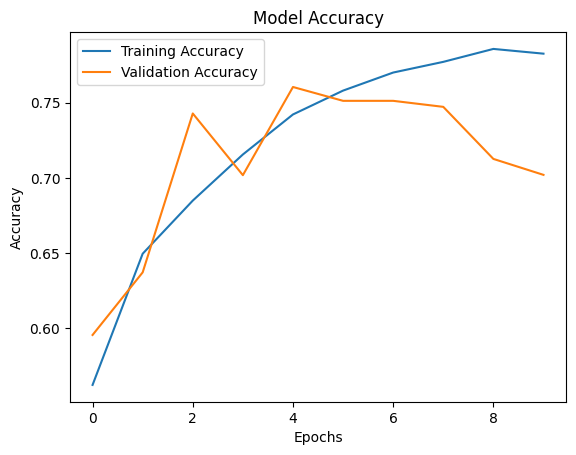

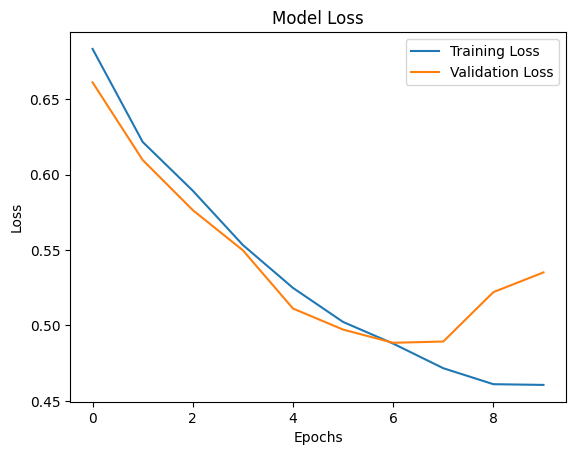

In [14]:
plt.plot(history_model_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_dropout.history['loss'], label='Training Loss')
plt.plot(history_model_dropout.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

all Layer dropout 50


In [16]:
from tensorflow.keras import models, layers

# Build the model
model_dropout = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history_model_dropout = model_dropout.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 411ms/step - accuracy: 0.5260 - loss: 0.8483 - val_accuracy: 0.6406 - val_loss: 0.6143
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accuracy: 0.6354 - loss: 0.6238 - val_accuracy: 0.6508 - val_loss: 0.5916
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 159ms/step - accuracy: 0.6934 - loss: 0.5750 - val_accuracy: 0.7060 - val_loss: 0.5452
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 154ms/step - accuracy: 0.7394 - loss: 0.5269 - val_accuracy: 0.7462 - val_loss: 0.5283
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 165ms/step - accuracy: 0.7674 - loss: 0.4831 - val_accuracy: 0.7506 - val_loss: 0.5371
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.7790 - loss: 0.4649 - val_accuracy: 0.7608 - val_loss: 0.4803
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.8017 - loss: 0.4365 - val_accuracy: 0.8014 - val_loss: 0.4344
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.8126 - loss

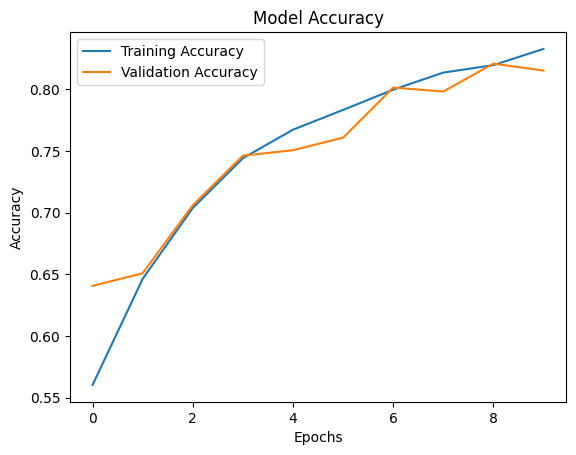

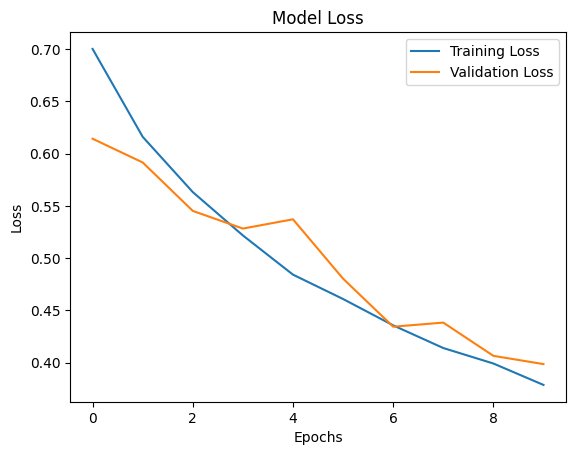

In [18]:
plt.plot(history_model_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_dropout.history['loss'], label='Training Loss')
plt.plot(history_model_dropout.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


L2 Regularization

In [19]:
from tensorflow.keras import models, layers, regularizers

# Build the model with L2 regularization
model_l2 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [20]:

# Train the model
history_model_l2 = model_l2.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.6229 - loss: 0.7454 - val_accuracy: 0.7326 - val_loss: 0.5854
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.7314 - loss: 0.5776 - val_accuracy: 0.7360 - val_loss: 0.5624
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 139ms/step - accuracy: 0.7737 - loss: 0.5285 - val_accuracy: 0.7462 - val_loss: 0.5643
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.7869 - loss: 0.5067 - val_accuracy: 0.7940 - val_loss: 0.4937
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 154ms/step - accuracy: 0.8075 - loss: 0.4755 - val_accuracy: 0.7908 - val_loss: 0.5086
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.8232 - loss: 0.4583 - val_accuracy: 0.7914 - val_loss: 0.5067
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.8227 - loss: 0.4497 - val_accuracy: 0.8130 - val_loss: 0.4746
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.8394 - loss: 0

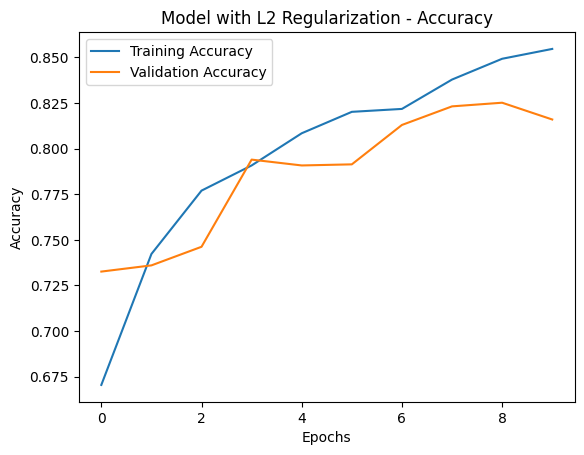

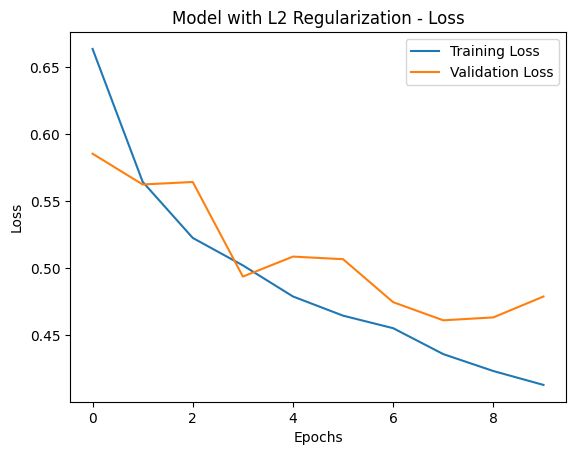

In [21]:

# Plot results (same as before)
plt.plot(history_model_l2.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_l2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with L2 Regularization - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_l2.history['loss'], label='Training Loss')
plt.plot(history_model_l2.history['val_loss'], label='Validation Loss')
plt.title('Model with L2 Regularization - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Combine Dropuout with 30 and L2 with Lambda 0.001

In [22]:
from tensorflow.keras import models, layers, regularizers

# Build the model with Dropout + L2
model_dropout_l2 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    
    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),  # Dropout after pooling
    
    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),  # Dropout after pooling
    
    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),  # Dropout after pooling
    
    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),  # Dropout before output
    layers.Dense(1, activation='sigmoid')  # No regularization on output layer
])

# Compile the model dropout and L2
model_dropout_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [23]:

# Train the model
history_dropout_l2 = model_dropout_l2.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 200ms/step - accuracy: 0.5522 - loss: 0.8589 - val_accuracy: 0.6762 - val_loss: 0.6358
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 317ms/step - accuracy: 0.6842 - loss: 0.6322 - val_accuracy: 0.7196 - val_loss: 0.6037
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 159ms/step - accuracy: 0.7230 - loss: 0.5861 - val_accuracy: 0.7324 - val_loss: 0.5745
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.7384 - loss: 0.5653 - val_accuracy: 0.7566 - val_loss: 0.5424
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 159ms/step - accuracy: 0.7524 - loss: 0.5555 - val_accuracy: 0.7766 - val_loss: 0.5173
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 175ms/step - accuracy: 0.7674 - loss: 0.5374 - val_accuracy: 0.7558 - val_loss: 0.5486
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.7751 - loss: 0.5303 - val_accuracy: 0.7622 - val_loss: 0.5279
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 154ms/step - accuracy: 0.7872 - lo

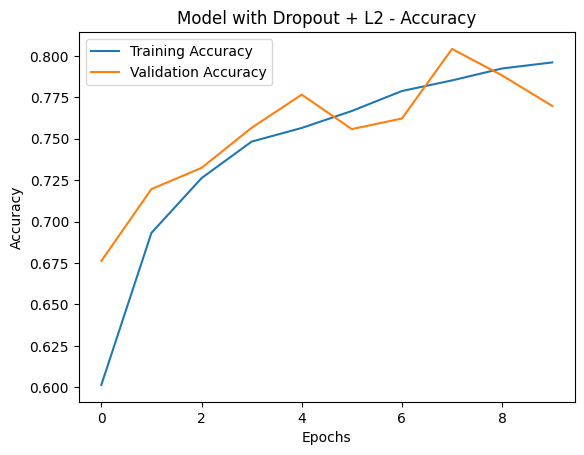

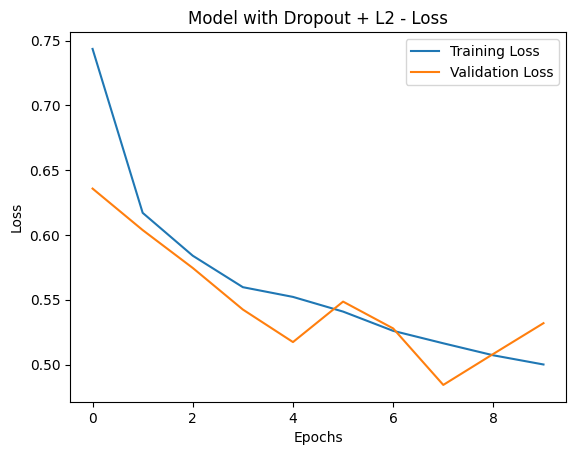

In [25]:

# Plot results
plt.plot(history_dropout_l2.history['accuracy'], label='Training Accuracy')
plt.plot(history_dropout_l2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with Dropout + L2 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_dropout_l2.history['loss'], label='Training Loss')
plt.plot(history_dropout_l2.history['val_loss'], label='Validation Loss')
plt.title('Model with Dropout + L2 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Early Stopping


In [1]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

# Basic CNN model (original)
model_basic = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_basic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,         # Stop after 3 epochs without improvement
    restore_best_weights=True  # Restore the best model weights
)


In [7]:

# Train the model with EarlyStopping
history_basic = model_basic.fit(
    train_generator,
    epochs=10,          # Set a high max epoch (EarlyStopping will stop early)
    validation_data=val_generator,
    callbacks=[early_stopping]  # Add EarlyStopping
)


d:\Project\python\1GN\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 409ms/step - accuracy: 0.6106 - loss: 0.6560 - val_accuracy: 0.7458 - val_loss: 0.5083
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accuracy: 0.7565 - loss: 0.4926 - val_accuracy: 0.7948 - val_loss: 0.4398
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 197ms/step - accuracy: 0.8193 - loss: 0.3967 - val_accuracy: 0.8162 - val_loss: 0.3919
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 285s 457ms/step - accuracy: 0.8666 - loss: 0.3070 - val_accuracy: 0.8228 - val_loss: 0.3898
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 165ms/step - accuracy: 0.9099 - loss: 0.2176 - val_accuracy: 0.8250 - val_loss: 0.4201
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.9564 - loss: 0.1191 - val_accuracy: 0.8210 - val_loss: 0.5291
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 199ms/step - accuracy: 0.9796 - loss: 0.0620 - val_accuracy: 0.8124 - val_loss: 0.6574


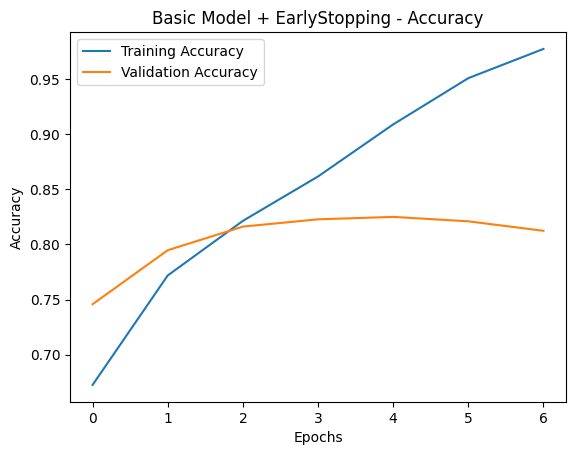

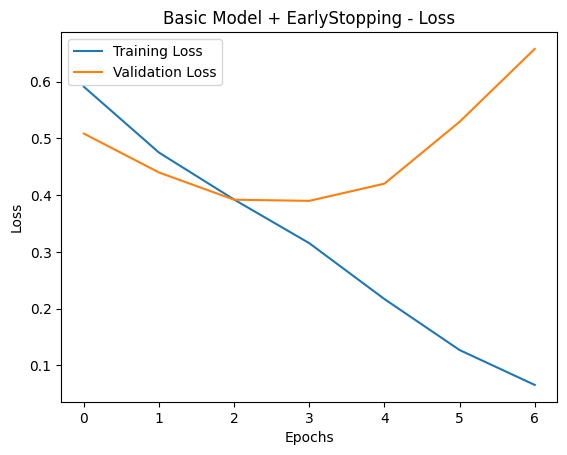

Training stopped at epoch 7


In [8]:

# Plot results
plt.plot(history_basic.history['accuracy'], label='Training Accuracy')
plt.plot(history_basic.history['val_accuracy'], label='Validation Accuracy')
plt.title('Basic Model + EarlyStopping - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_basic.history['loss'], label='Training Loss')
plt.plot(history_basic.history['val_loss'], label='Validation Loss')
plt.title('Basic Model + EarlyStopping - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Print the number of epochs used
print(f"Training stopped at epoch {len(history_basic.history['loss'])}")

Data Agmentation

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


d:\Project\python\1GN\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 260ms/step - accuracy: 0.5432 - loss: 0.7037 - val_accuracy: 0.6746 - val_loss: 0.5922
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 332ms/step - accuracy: 0.6858 - loss: 0.5882 - val_accuracy: 0.7390 - val_loss: 0.5144
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 158s 253ms/step - accuracy: 0.7404 - loss: 0.5254 - val_accuracy: 0.7944 - val_loss: 0.4444
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.7558 - loss: 0.4967 - val_accuracy: 0.7308 - val_loss: 0.5394
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.7706 - loss: 0.4799 - val_accuracy: 0.8206 - val_loss: 0.4181
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 314ms/step - accuracy: 0.7877 - loss: 0.4526 - val_accuracy: 0.8326 - val_loss: 0.3726
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.7953 - loss: 0.4357 - val_accuracy: 0.8286 - val_loss: 0.3775
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.8061 -

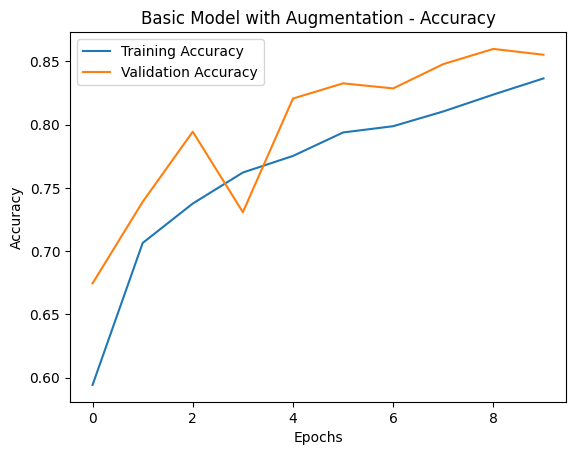

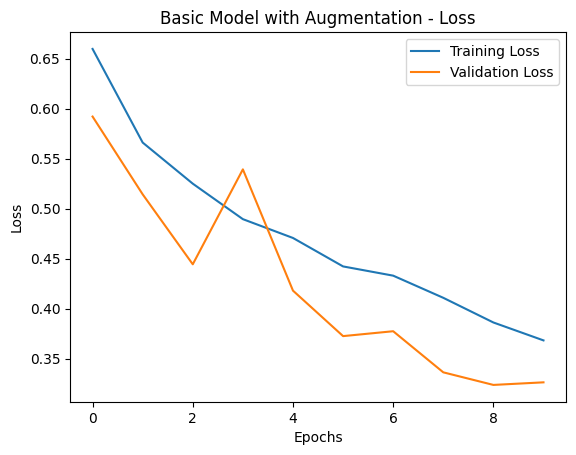

In [10]:
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmented data generator for training
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validation data should NOT be augmented (only rescaled)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator_augmented = train_datagen_augmented.flow_from_directory(
    train_dir,               # Your training directory
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,          # Your validation directory
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Basic CNN model
model_basic_aug = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_basic_aug.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train with augmented data
history_basic_aug = model_basic_aug.fit(
    train_generator_augmented,
    epochs=10,  # You can adjust number of epochs
    validation_data=val_generator
)

# Plot results
plt.plot(history_basic_aug.history['accuracy'], label='Training Accuracy')
plt.plot(history_basic_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Basic Model with Augmentation - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_basic_aug.history['loss'], label='Training Loss')
plt.plot(history_basic_aug.history['val_loss'], label='Validation Loss')
plt.title('Basic Model with Augmentation - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv('output.csv', sep=';')
models = df['Model'].unique()

# 1. TRAINING PLOT (All models)
plt.figure(figsize=(10, 5))

# Training Accuracy
plt.subplot(1, 2, 1)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['accuracy'], label=model)
plt.title('Training Accuracy (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['loss'], label=model)
plt.title('Training Loss (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 2. VALIDATION PLOT (All models)
plt.figure(figsize=(10, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['val_accuracy'], label=model)
plt.title('Validation Accuracy (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Validation Loss
plt.subplot(1, 2, 2)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['val_loss'], label=model)
plt.title('Validation Loss (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

KeyError: 'Model'

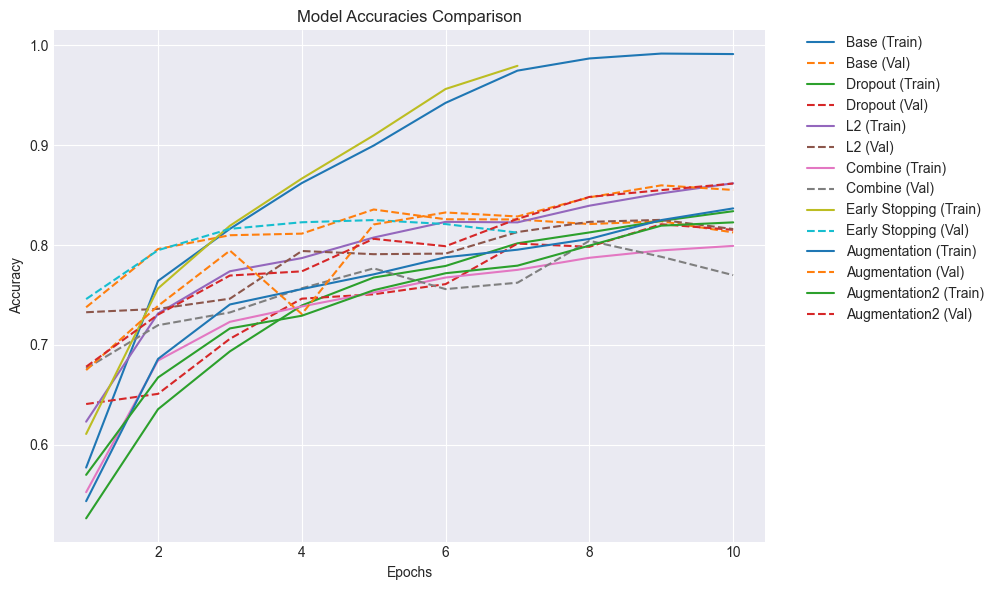

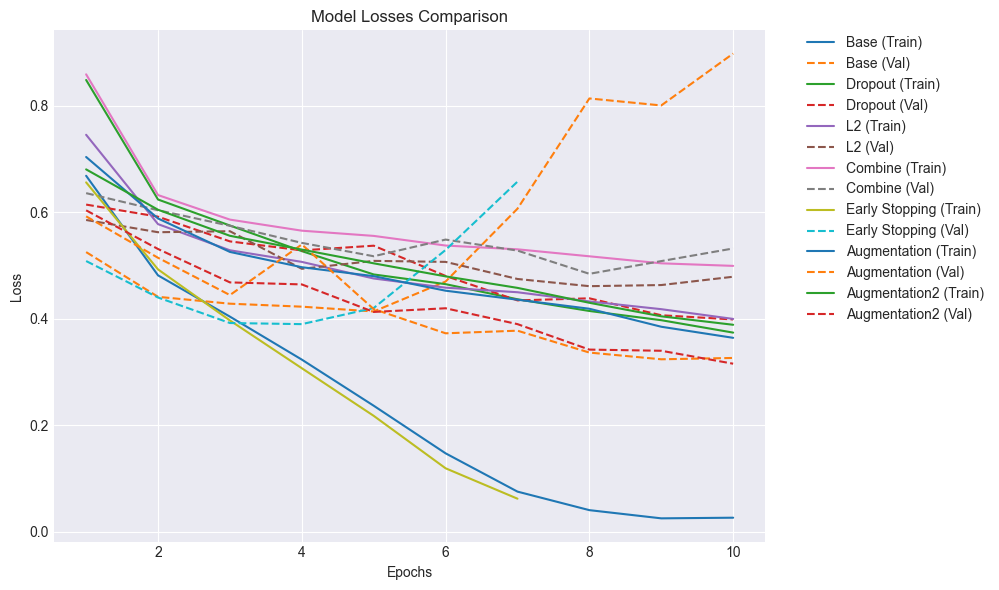

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
# Make sure 'output.csv' is in the same directory as your script,
# or provide the full path to the file.
try:
    df = pd.read_csv('output.csv', sep=';')
except FileNotFoundError:
    print("Error: 'output.csv' not found. Please check the file path.")
    exit()

models = df['Model'].unique()

# Set style
# Using a specific and available seaborn-like style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    print("Warning: 'seaborn-v0_8-darkgrid' style not found. Using default style.")
    # You can list available styles if you want to see options:
    # print("Available styles:", plt.style.available)

plt.rcParams['figure.figsize'] = [12, 6]

# 1. ALL ACCURACIES PLOT (Training + Validation)
plt.figure()
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['accuracy'], 
             label=f'{model} (Train)', linestyle='-')
    plt.plot(model_data['Epoch'], model_data['val_accuracy'], 
             label=f'{model} (Val)', linestyle='--')
plt.title('Model Accuracies Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
# Adjust legend position to avoid overlap if many models
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

# 2. ALL LOSSES PLOT (Training + Validation)
plt.figure()
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['loss'], 
             label=f'{model} (Train)', linestyle='-')
    plt.plot(model_data['Epoch'], model_data['val_loss'], 
             label=f'{model} (Val)', linestyle='--')
plt.title('Model Losses Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# Adjust legend position
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()
